# System Tests

In [2]:
import random
import jax
import jax.numpy as jnp

In [4]:
from utils import batch_mul
import samplers
from sde import VPSDE, subVPSDE, VESDE
import likelihood

2026-03-16 00:07:29.476863: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### General Variables

In [5]:
batch_size = 4
normal = jax.random.normal
jax.random.normal = lambda key, shape: jnp.full(shape, 0.5)

## Utility Functions

### Batch Multiplications

In [6]:
a = jnp.array([1.0,2.0, 0.5, 10.0]) # (4,)
b = jnp.ones((batch_size, 32,32,3)) # (4,32,32,3)
result = batch_mul(a,b)

assert result.shape == b.shape, f'Expected {b.shape} array, got {result.shape}'

expected = a.reshape(batch_size, 1,1,1)

assert jnp.allclose(result, expected), "Result does not match expected product"

## SDEs

In [7]:
shape = (batch_size,4,4,3)
x = jnp.ones(shape)
t = jnp.full((batch_size,),0.5)
score = jnp.full(shape, 0.7)

### VP SDE

In [8]:
vp_sde = VPSDE(0.1, 20, 1000)
rng = jax.random.PRNGKey(0)
mean, std = vp_sde.marginal_prob(x,t)
f, g = vp_sde.sde(x,t)
prior_sample = vp_sde.prior_sampling(rng, shape)
rev_f, rev_g = vp_sde.reverse_sde(x,t,score,False)
rev_f_flow, _ = vp_sde.reverse_sde(x,t,score,True)

expected_f = jnp.full(shape, -5.025)
expected_g = jnp.full((batch_size,), 3.17017)
expected_mean = jnp.full(shape, 0.281184)
expected_std = jnp.full((batch_size,), 0.959654)
expected_sample = jnp.full(shape, 0.5)
expected_rev_f = jnp.full(shape, -12.06)
expected_rev_g = jnp.full((batch_size,),3.17017)
expected_rev_f_flow = jnp.full(shape, -8.5425)


assert jnp.allclose(f, expected_f), 'Mismatch in f'
assert jnp.allclose(g, expected_g), 'Mismatch in g'
assert jnp.allclose(mean, expected_mean), 'Mismatch in mean'
assert jnp.allclose(std, expected_std), 'Mismatch in std'
assert jnp.allclose(prior_sample, expected_sample), 'Mismatch in prior sample'
assert jnp.allclose(rev_f, expected_rev_f), 'Mismatch in rev_f'
assert jnp.allclose(rev_g, expected_rev_g), 'Mismatch in rev_g'
assert jnp.allclose(rev_f_flow, expected_rev_f_flow), 'Mismatch in rev_f when probability flow=True'

### Sub-VP SDE

In [9]:
sub_vp_sde = subVPSDE(0.1, 20, 1000)
rng = jax.random.PRNGKey(0)
mean, std = sub_vp_sde.marginal_prob(x,t)
f, g = sub_vp_sde.sde(x,t)
prior_sample = sub_vp_sde.prior_sampling(rng, shape)
rev_f, rev_g = sub_vp_sde.reverse_sde(x,t,score,False)
rev_f_flow, _ = sub_vp_sde.reverse_sde(x,t,score,True)

expected_f = jnp.full(shape, -5.025)
expected_g = jnp.full((batch_size,), 3.16024)
expected_mean = jnp.full(shape, 0.281184)
expected_std = jnp.full((batch_size,), 0.92093)
expected_sample = jnp.full(shape, 0.5)
expected_rev_f = jnp.full(shape, -12.016024)
expected_rev_g = jnp.full((batch_size,), 3.16024)
expected_rev_f_flow = jnp.full(shape, -8.5205)


assert jnp.allclose(f, expected_f), 'Mismatch in f'
assert jnp.allclose(g, expected_g), 'Mismatch in g'
assert jnp.allclose(mean, expected_mean), 'Mismatch in mean'
assert jnp.allclose(std, expected_std), 'Mismatch in std'
assert jnp.allclose(prior_sample, expected_sample), 'Mismatch in prior sample'
assert jnp.allclose(rev_f, expected_rev_f), 'Mismatch in rev_f'
assert jnp.allclose(rev_g, expected_rev_g), 'Mismatch in rev_g'
assert jnp.allclose(rev_f_flow, expected_rev_f_flow), 'Mismatch in rev_f when probability flow=True'

### VE SDE

In [10]:
ve_sde = VESDE(0.01, 50, 10)
rng = jax.random.PRNGKey(0)
mean, std = ve_sde.marginal_prob(x,t)
f, g = ve_sde.sde(x,t)
prior_sample = ve_sde.prior_sampling(rng, shape)
rev_f, rev_g = ve_sde.reverse_sde(x,t,score,False)
rev_f_flow, _ = ve_sde.reverse_sde(x,t,score,True)

expected_f = jnp.full(shape, 0)
expected_g = jnp.full((batch_size,), 2.918423)
expected_mean = jnp.full(shape, 1.0)
expected_std = jnp.full((batch_size,), 0.707106)
expected_sample = jnp.full(shape, 0.5)*50
expected_rev_f = jnp.full(shape, -5.962035)
expected_rev_g = jnp.full((batch_size,), 2.918423)
expected_rev_f_flow = jnp.full(shape, -2.9810176)


assert jnp.allclose(f, expected_f), 'Mismatch in f'
assert jnp.allclose(g, expected_g), 'Mismatch in g'
assert jnp.allclose(mean, expected_mean), 'Mismatch in mean'
assert jnp.allclose(std, expected_std), 'Mismatch in std'
assert jnp.allclose(prior_sample, expected_sample), 'Mismatch in prior sample'
assert jnp.allclose(rev_f, expected_rev_f), 'Mismatch in rev_f'
assert jnp.allclose(rev_g, expected_rev_g), 'Mismatch in rev_g'
assert jnp.allclose(rev_f_flow, expected_rev_f_flow), 'Mismatch in rev_f when probability flow=True'

## Score Functions

In [11]:
import flax.linen as nn
from score import get_score_fn

class TinyModel(nn.Module):
    @nn.compact
    def __call__(self, x, t, train=False):
        return jnp.full_like(x, 2.0)

model  = TinyModel()
params = model.init(rng, x, t)

# VESDE: score == model output / std
_, std = ve_sde.marginal_prob(jnp.zeros_like(x), t)
expected = batch_mul(2.0 / std, jnp.ones_like(x))
score = get_score_fn(ve_sde, model, params)(x, t)
assert jnp.allclose(score, expected), f'VESDE score: {score[0,0,0,0]}'

# VPSDE: score == -output / std
_, std = vp_sde.marginal_prob(jnp.zeros_like(x), t)
expected = -batch_mul(2.0 / std, jnp.ones_like(x))
score = get_score_fn(vp_sde, model, params)(x, t)
assert jnp.allclose(score, expected, atol=1e-5), f'VPSDE score mismatch'
print('score_fn OK')

score_fn OK


## Losses

In [12]:
from losses import get_loss_fn

for cont in [False, True]:
    loss_fn = get_loss_fn(vp_sde, model, train=False, reduce_mean=True, continuous=cont)
    loss = loss_fn(rng, params, x)
    assert loss.shape == (),      f'loss not scalar: {loss.shape}'
    assert jnp.isfinite(loss),    f'loss not finite: {loss}'
    assert loss >= 0,             f'negative loss: {loss}'
    print(f'loss continuous={cont}: {float(loss):.4f} OK')

loss continuous=False: 2.2621 OK
loss continuous=True: 2.2500 OK


## Samplers

### Simple Predictor and Correctors

In [13]:
shape = (batch_size,4,4,3)
x = jnp.ones(shape)
t = jnp.full((batch_size,),0.5)

In [14]:
predictor = samplers.Predictor()
corrector = samplers.Corrector()

pred_output = predictor.update_fn(rng=None, x=x, t=None)
corr_output = corrector.update_fn(rng=None, x=x, t=None)

assert jnp.allclose(pred_output[0],x), 'Predictor output does not match expected value'
assert jnp.allclose(pred_output[1],x), 'Predictor mean does not match expected value'
assert jnp.allclose(corr_output[0],x), 'Corrector output does not match expected value'
assert jnp.allclose(corr_output[1],x), 'Corrector mean does not match expected value'

### Dummy Objects and Functions

In [15]:
class dummySDE:
    def __init__(self):
        self.N = 10
        self.T = 1.
    
    def reverse_sde(self, x,t,score,probability_flow=False):
        f = jnp.full_like(x,2.)
        batch_size=x.shape[0]
        G = jnp.full((batch_size,), 3.)
        return f,G
    
    def prior_sampling(self, rng, shape):
        return jnp.ones(shape)
    
    def discretize(self, x, t):
        return jnp.full_like(x, 8.3), jnp.full((x.shape[0],), 3.)
    

sde = dummySDE()

In [16]:
class dummyVPSDE(VPSDE):
    def __init__(self):
        self.N = 10
        self.T = 1.0
        self.discrete_betas = jnp.full((self.N), 0.4)
        self.alphas = jnp.full((self.N), 0.6)
    
    def reverse_sde(self, x,t,score,probability_flow=False):
        f = jnp.full_like(x,2.)
        batch_size=x.shape[0]
        G = jnp.full((batch_size,), 3.)
        return f,G

    def marginal_prob(self, x, t):
        return 0, jnp.full(t.shape, 0.3)

vp_sde = dummyVPSDE()

In [17]:
class dummyVESDE(VESDE):
    def __init__(self):
        self.N = 10
        self.T = 1
        self.discrete_sigmas = jnp.array([0.5, 0.3]*5)

    def marginal_prob(self, x, t):
        return 0, jnp.full(t.shape, 0.3)

ve_sde = dummyVESDE()

In [18]:
def dummy_score_fn(x,t):
    return jnp.full_like(x, 0.7)

### Euler-Maruyama Predictor

$x_{mean} = x-f*dt$

$x_{sample} = x_{mean}+G*\sqrt{dt}*z$

In [19]:
predictor = samplers.EulerMaruyamaPredictor(sde,dummy_score_fn, False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng,x,t)

expected_mean = jnp.full(shape,0.8)
expected_sample = jnp.full(shape, (16+3*jnp.sqrt(10))/20)

assert jnp.allclose(x_sample, expected_sample, atol=1e-4), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-4), "Predictor mean does not match expected value"

### Reverse Diffusion Predictor
$f = f - G²·score$

$x_{mean} = x-f$ 

$x_{sample} = x_{mean}+G*z$

In [20]:
predictor = samplers.ReverseDiffusionPredictor(sde, dummy_score_fn, False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng,x,t)

expected_mean = jnp.full(shape, -1.)
expected_sample = jnp.full(shape, 0.5)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Predictor mean does not match expected value"

### Ancestral Sampling Predictor

#### VP SDE

$x_{mean} = \frac{x+\beta_i * s(x, i)}{\sqrt{1-\beta_i}}$

$x_{sample} = x_{mean} + \sqrt{\beta_i}*z$

In [21]:
predictor = samplers.AncestralSamplingPredictor(vp_sde, dummy_score_fn, probability_flow=False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 32*jnp.sqrt(15)/75)
expected_sample = jnp.full(shape, (64*jnp.sqrt(15)+15*jnp.sqrt(10))/150)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Predictor mean does not match expected value"

#### VE SDE

$x_{mean} = x+(\sigma_i^2-\sigma_{i-1}^2)*s(x,i)$

$x_{sample} = x_{mean}+\sqrt{\frac{\sigma_{i-1}^2*(\sigma_i^2-\sigma_{i-1}^2)}{\sigma_i^2}}*z$

In [22]:
predictor = samplers.AncestralSamplingPredictor(ve_sde, dummy_score_fn, probability_flow=False)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = predictor.update_fn(rng,x,t)

expected_mean = jnp.full(shape, 139/125)
expected_sample = jnp.full(shape, 154/125)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Predictor output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Predictor mean does not match expected value"

### LangevinCorrector

#### VP SDE

In [23]:
corrector = samplers.LangevinCorrector(vp_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.0638997)
expected_sample = jnp.full(shape, 1.119228)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

#### VE SDE

In [24]:
corrector = samplers.LangevinCorrector(ve_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.0857143)
expected_sample = jnp.full(shape, 1.1571429)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

### Annealed Langevin Corrector

#### VP SDE

In [25]:
corrector = samplers.AnnealedLangevinCorrector(vp_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.0247499)
expected_sample = jnp.full(shape, 1.0479878)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

#### VE SDE

In [26]:
corrector = samplers.AnnealedLangevinCorrector(ve_sde, dummy_score_fn, 0.1, 2)
rng = jax.random.PRNGKey(0)
x_sample, x_mean = corrector.update_fn(rng, x, t)

expected_mean = jnp.full(shape, 1.03252)
expected_sample = jnp.full(shape, 1.06252)

assert jnp.allclose(x_sample, expected_sample, atol=1e-5), "Corrector output does not match expected value"
assert jnp.allclose(x_mean, expected_mean, atol=1e-5), "Corrector mean does not match expected value"

### PC-Sampling

In [27]:
predictor, corrector = samplers.Predictor(), samplers.Corrector()
inverse_scaler = lambda x: x*2.0

sampler_fn = samplers.pc_sampler(sde, shape, predictor, corrector, inverse_scaler, 1, True)
rng = jax.random.PRNGKey(0)
x_final, evals = sampler_fn(rng)

expected_evals = sde.N*2
expected_x = jnp.full(shape, 2.0)

assert evals == expected_evals, 'Mismatch in number of evaluations'
assert jnp.allclose(x_final, expected_x), "Sampler output does not match expected value"

### ODE-Sampling

In [28]:
inverse_scaler = lambda x: x*2.0

sampler = samplers.ode_sampler(
    sde=sde,
    score_fn=dummy_score_fn,
    shape=shape,
    inverse_scaler=inverse_scaler,
    denoise=True
)

rng = jax.random.PRNGKey(0)
x_final, nfe = sampler(rng)
assert x_final.shape == shape, "Shape mismatch"
assert nfe > 0, "Zero function evaluations"

## Likelihood Computation

In [29]:
likelihood_fn = likelihood.get_likelihood_fn(vp_sde, dummy_score_fn, inverse_scaler)
rng = jax.random.PRNGKey(0)
log_likelihood, bpd, z, nfe = likelihood_fn(rng, x)

assert jnp.all(~jnp.isnan(log_likelihood)), 'NaN in Log-likelihood'
assert jnp.all(~jnp.isnan(bpd)), 'NaN in Bits/dimension'
assert jnp.all(~jnp.isnan(z)), 'NaN in z'
assert nfe > 0, 'Zero function evaluations'

## SDEs + Predictors/Correctors

In [30]:
shape = (batch_size,4,4,3)
x = jnp.ones(shape)
t = jnp.full((batch_size,),0.5)
rng = jax.random.PRNGKey(0)

In [31]:
vp_sde = VPSDE(0.1, 20, 1000)
sub_vp_sde = subVPSDE(0.1, 20, 1000)
ve_sde = VESDE(0.01, 50, 10)

### Euler-Maruyama

In [32]:
em_vp = samplers.EulerMaruyamaPredictor(vp_sde, dummy_score_fn, False)
x_sample, x_mean = em_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [33]:
em_sub_vp = samplers.EulerMaruyamaPredictor(sub_vp_sde, dummy_score_fn, False)
x_sample, x_mean = em_sub_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [34]:
em_ve = samplers.EulerMaruyamaPredictor(ve_sde, dummy_score_fn, False)
x_sample, x_mean = em_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Reverse Diffusion

In [35]:
rd_vp = samplers.ReverseDiffusionPredictor(vp_sde, dummy_score_fn, False)
x_sample, x_mean = rd_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [36]:
rd_sub_vp = samplers.ReverseDiffusionPredictor(sub_vp_sde, dummy_score_fn, False)
x_sample, x_mean = rd_sub_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

AttributeError: 'subVPSDE' object has no attribute 'discretize'

In [37]:
rd_ve = samplers.ReverseDiffusionPredictor(ve_sde, dummy_score_fn, False)
x_sample, x_mean = rd_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Ancestral Sampling

In [38]:
as_vp = samplers.AncestralSamplingPredictor(vp_sde, dummy_score_fn, False)
x_sample, x_mean = as_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [39]:
as_ve = samplers.AncestralSamplingPredictor(ve_sde, dummy_score_fn, False)
x_sample, x_mean = as_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Langevin

In [40]:
l_vp = samplers.LangevinCorrector(vp_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = l_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [41]:
l_ve = samplers.LangevinCorrector(ve_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = l_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### Annealed Langevin

In [42]:
al_vp = samplers.AnnealedLangevinCorrector(vp_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = al_vp.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

In [43]:
al_ve = samplers.AnnealedLangevinCorrector(ve_sde, dummy_score_fn, 0.1, 10)
x_sample, x_mean = al_ve.update_fn(rng, x, t)
assert jnp.all(~jnp.isnan(x_mean)), 'NaN in mean'
assert jnp.all(~jnp.isnan(x_sample)), 'NaN in sample'

### PC Sampling with actual SDEs

In [44]:
jax.random.normal = normal

In [45]:
rng = jax.random.PRNGKey(0)
ve_sde = VESDE(0.01, 50, 10)
as_ve = samplers.AncestralSamplingPredictor(ve_sde, dummy_score_fn, False)
al_ve = samplers.AnnealedLangevinCorrector(ve_sde, dummy_score_fn, 0.1, 10)
inverse_scaler = lambda x: x*2.0
sampler = samplers.pc_sampler(ve_sde, shape, as_ve, al_ve, inverse_scaler, n_steps=100, denoise=True)
x_final, evals = sampler(rng)
assert jnp.all(~jnp.isnan(x_final)), 'NaN in sample'
print(x_final)

[[[[4141.844  4309.8774 4297.529 ]
   [4261.526  4116.1187 4321.9917]
   [4136.839  4037.0256 4115.0615]
   [4423.594  4236.181  4275.4814]]

  [[4347.908  4415.6606 4306.944 ]
   [4399.8486 4418.3394 4121.6626]
   [4333.3887 4206.5156 4226.823 ]
   [4120.589  4281.6714 4311.901 ]]

  [[4401.71   4398.5864 4170.85  ]
   [4195.7856 4325.219  4362.443 ]
   [4387.384  4330.3975 4071.1853]
   [4407.471  4406.7905 4249.4526]]

  [[4505.7314 4333.3643 4240.2124]
   [4404.6006 4381.5615 4219.149 ]
   [4430.5063 4290.6445 4127.2563]
   [4225.572  4285.2593 4442.9434]]]


 [[[4065.6284 4391.449  4440.281 ]
   [4161.702  4357.9805 4206.9956]
   [4440.5796 4310.552  4355.5337]
   [4420.982  4208.85   4512.6865]]

  [[4454.0967 4294.1064 4131.015 ]
   [4438.7837 4197.7563 4455.006 ]
   [4191.0405 4711.494  4094.0916]
   [4472.238  4437.8955 4300.188 ]]

  [[4277.069  4352.968  4256.549 ]
   [4310.456  4499.4087 4334.9805]
   [4459.9253 4633.9966 4359.184 ]
   [4513.461  4127.2764 4275.1694]]

  [[

## Entire System Test

In [46]:
from config import get_config_local
from train import train
from score import get_score_fn

In [47]:
configuration = get_config_local()

2026-03-16 00:08:12.605197: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Training for 100 iterations...
Step 10/100, Loss: 3353.87
Step 20/100, Loss: 2932.83
Step 30/100, Loss: 2731.00
Step 40/100, Loss: 2199.27
Step 50/100, Loss: 2096.91
Step 60/100, Loss: 1823.09
Step 70/100, Loss: 1496.61
Step 80/100, Loss: 875.62
Step 90/100, Loss: 1840.70
Step 100/100, Loss: 2198.63


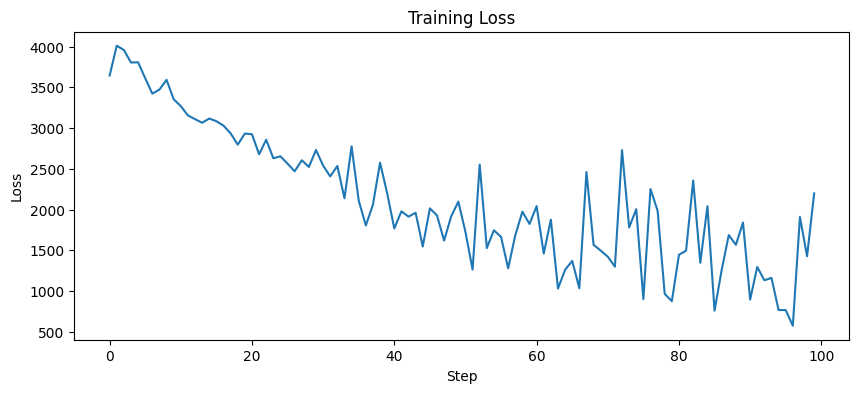

Saved loss_curve.png


2026-03-16 00:09:05.931544: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [48]:
params, model, sde = train(configuration)

In [49]:
from samplers import get_sampler
import jax.numpy as jnp
import jax

In [50]:
score_fn = get_score_fn(sde, model, params, continuous=configuration.training.continuous)
sampler = get_sampler(sde, score_fn, configuration)
rng = jax.random.PRNGKey(0)
x_final, _ = sampler(rng)
print(x_final)

[[[[-1.23260902e+02 -5.37774658e+01  4.77109528e+01]
   [ 3.10701538e+02 -9.41607590e+01  5.42904243e+01]
   [ 1.53872360e+02  5.58864563e+02  5.22893433e+02]
   ...
   [ 2.89275818e+01  3.46202332e+02  5.02357666e+02]
   [ 1.38117645e+02 -6.52959595e+02 -3.08013397e+02]
   [ 1.44542862e+02  1.17444191e+02 -1.44304230e+02]]

  [[-7.73591614e+01  1.30513748e+02  6.04690247e+02]
   [-2.05672577e+02  1.60992188e+02  3.63137634e+02]
   [-6.20488220e+02  2.56828033e+02  5.09946198e+02]
   ...
   [ 6.49314346e+01  1.54749741e+02 -2.09894135e+02]
   [-1.60051666e+02 -2.45338074e+02 -2.60011444e+02]
   [ 3.34987183e+02 -9.29083862e+01  3.58591675e+02]]

  [[-4.88685532e+01  7.15761032e+01 -9.40108681e+00]
   [ 5.62406387e+01  1.01567032e+02  1.48213684e+02]
   [-1.36874985e+02  2.22797028e+02  1.99009705e+01]
   ...
   [-6.01666069e+01  4.57305603e+02  8.47592773e+02]
   [-2.85861969e+02 -2.27239700e+02  6.57131424e+01]
   [-1.06799011e+02  2.49192215e+02  5.91729980e+02]]

  ...

  [[ 6.26936

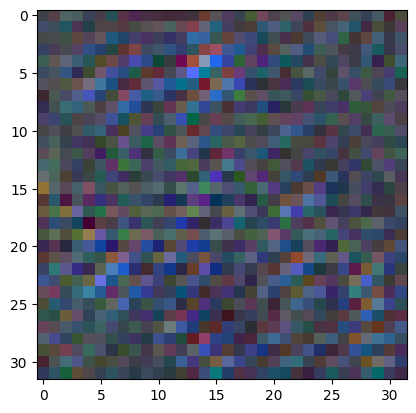

In [58]:
import matplotlib.pyplot as plt
import numpy as np

img = np.array(x_final[0])
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img)
plt.show()